In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace import sarimax
from statsmodels.tsa.api import ExponentialSmoothing

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [15]:
data = pd.read_csv('AirPassengers (1).csv')
data['Month'] = pd.to_datetime(data['Month'])
data = data.set_index('Month')
val_data = data.copy()
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


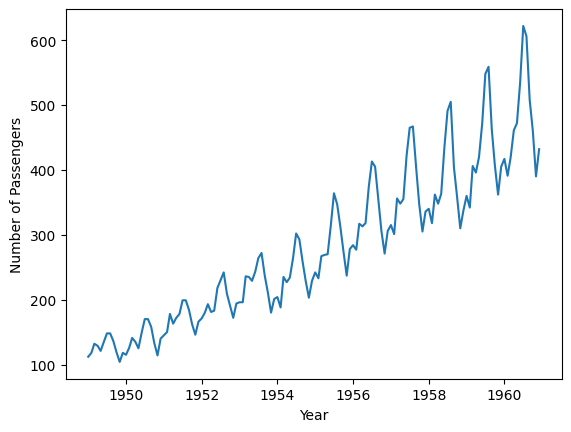

In [4]:
plt.plot(data)
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

In [5]:
data = data.asfreq('MS')

In [6]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(data)
model_single_fit = model.fit()

In [7]:
forecast_single = model_single_fit.forecast(6)
forecast_single

1961-01-01    431.791781
1961-02-01    431.791781
1961-03-01    431.791781
1961-04-01    431.791781
1961-05-01    431.791781
1961-06-01    431.791781
Freq: MS, dtype: float64

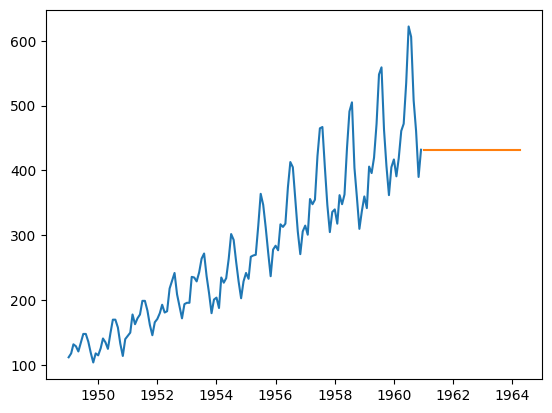

In [11]:
forecast = model_single_fit.forecast(40)
plt.plot(data)
plt.plot(forecast)

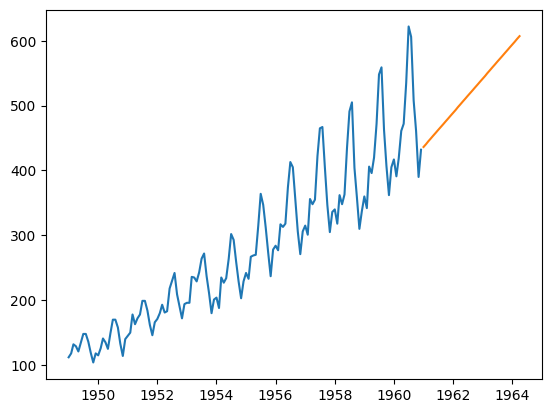

In [12]:
from statsmodels.tsa.api import Holt

model_double = Holt(data)
model_double_fit = model_double.fit()

forecast_double = model_double_fit.forecast(40)
plt.plot(data)
plt.plot(forecast_double)

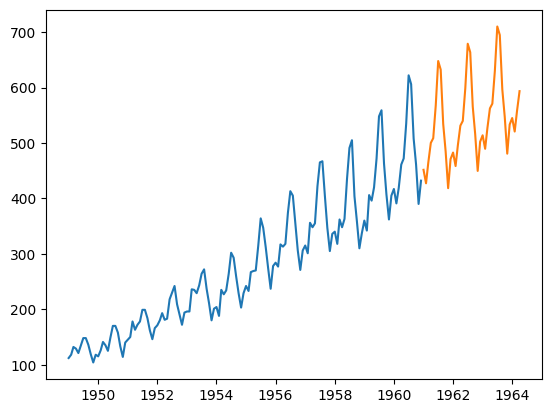

In [14]:
from statsmodels.tsa.api import ExponentialSmoothing
model_triple = ExponentialSmoothing(data,
                                   seasonal_periods=12,
                                   trend='add',
                                   seasonal='add')
model_triple_fit = model_triple.fit()

forecast_triple = model_triple_fit.forecast(40)

plt.plot(data)
plt.plot(forecast_triple)

In [16]:
model_triple_fit.params

{'smoothing_level': 0.25254989686499935,
 'smoothing_trend': 9.765463812739731e-07,
 'smoothing_seasonal': 0.7474446031813125,
 'damping_trend': nan,
 'initial_level': 118.43092695514434,
 'initial_trend': 2.59469363494243,
 'initial_seasons': array([ -9.06562263,  -3.43708014,   9.00565253,   3.81742261,
         -4.93283548,   9.17620296,  21.3830049 ,  18.84610688,
          4.61900836, -14.34042469, -28.91443539, -12.43815072]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [27]:
val_data.shape

(144, 1)

In [28]:
val_data = val_data.asfreq('MS')

In [29]:
train = val_data.iloc[:-12]
test = val_data.iloc[-12:]

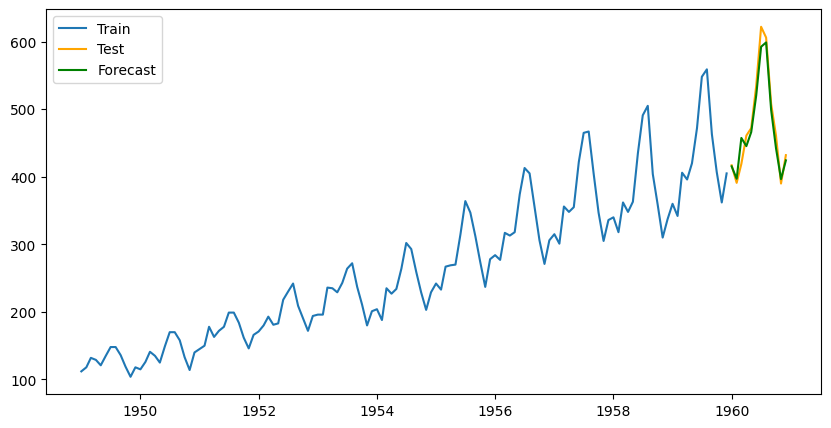

In [30]:
model = ExponentialSmoothing(train,
                            seasonal_periods=12,
                            trend='add',
                            seasonal='add')
fit = model.fit()
forecast = fit.forecast(len(test))

plt.figure(figsize=(10, 5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='orange')
plt.plot(forecast, label='Forecast', color='green')
plt.legend()
plt.show()

In [33]:
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 13.38
RMSE: 16.98
